In [75]:
N = "002"
DATE = "20260603"
controller_mode = 'original'
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../src/_base/epw/ED-TMYx.2023.epw'
occupancyProfile_csv = 'ETHlib/auxiliary/schedules_el_OFFICE.csv'

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import json

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = "ETHlib"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
from radiation import Location, Window

CITYLOC       = json.loads(Path(loc_json).read_text())
latitude_deg = CITYLOC['latitude_deg']
longitude_deg  = CITYLOC['longitude_deg']
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)
uq_json_path = Path(f"json/UQ/uq_top4_oat_heating_{DATE}_{N}.json")

In [ ]:
meter_path = "_data/Metering_ISO.csv"

meter_daily = load_meter_heating(
    meter_path,
    "Main Heating",
    GEOMETRY["FLOOR_AREA"],
    "D",
)

meter_hourly = load_meter_heating(
    meter_path,
    "Main Heating",
    GEOMETRY["FLOOR_AREA"],
    "h",
)

# RUN

In [3]:
def run_model(
    sampled_params,
    controller_mode="occupancy",
    occupancy_controller_params=None,
):
    p = merge_params(sampled_params, DEFAULT_PARAMS)

    HeatingDemand, HeatingEnergy, CoolingDemand, CoolingEnergy = [], [], [], []
    ElectricityOut, IndoorAir, OutsideTemp, SolarGains, COP = [], [], [], [], []
    ach_vent_hourly, ach_infl_hourly, h_ve_adj_hourly = [], [], []

    t_m_prev = 20.0

    heating_schedule = make_heating_schedule(year=year, p=p)

    ach_vent_baseline, ach_infl_baseline = make_ach(
        p=p,
        geometry=GEOMETRY,
        calc_ach=calc_ach,
    )

    base_occupancy_controller_params = {
        "n_people": p["max_occupancy"],
        "ach_vent_baseline": ach_vent_baseline,
    }

    if occupancy_controller_params is not None:
        base_occupancy_controller_params.update(occupancy_controller_params)

    occupancy_controller_params = base_occupancy_controller_params

    Office = make_zone(
        p=p,
        geometry=GEOMETRY,
        ach_vent=ach_vent_baseline,
        ach_infl=ach_infl_baseline,
        Zone=Zone,
        supply_system=supply_system,
        emission_system=emission_system,
    )

    SouthWindow = Window(
        azimuth_tilt=0,
        alititude_tilt=90,
        glass_solar_transmittance=0.7,
        glass_light_transmittance=0.8,
        area=GEOMETRY["WINDOW_AREA"] * p["_beta"],
    )

    for hour in range(8760):
        occupancy = occupancyProfile.loc[hour, "People"] * p["max_occupancy"]

        if controller_mode == "original":
            desired_ach = ach_vent_baseline

        elif controller_mode == "occupancy":
            desired_ach = occupancy_based_ach(
                hour=hour,
                occupancy=occupancy,
                **occupancy_controller_params,
            )

        else:
            raise ValueError(
                f"Unknown controller_mode: {controller_mode}. "
                "Use 'original' or 'occupancy'."
            )

        Office.ach_vent = desired_ach

        ach_vent_hourly.append(Office.ach_vent)
        ach_infl_hourly.append(Office.ach_infl)
        h_ve_adj_hourly.append(Office.h_ve_adj)

        Office.t_set_heating = heating_schedule[hour]

        internal_gains = (
            occupancy * p["gain_per_person"]
            + p["appliance_gains"] * Office.floor_area
        )

        t_out = EDI.weather_data["drybulb_C"][hour]

        altitude, azimuth = EDI.calc_sun_position(
            latitude_deg=latitude_deg,
            longitude_deg=longitude_deg,
            year=year,
            hoy=hour,
        )

        SouthWindow.calc_solar_gains(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
            horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour],
        )

        SouthWindow.calc_illuminance(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
            horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour],
        )

        Office.solve_energy(
            internal_gains=internal_gains,
            solar_gains=SouthWindow.solar_gains,
            t_out=t_out,
            t_m_prev=t_m_prev,
        )

        Office.solve_lighting(
            illuminance=SouthWindow.transmitted_illuminance,
            occupancy=occupancy,
        )

        t_m_prev = Office.t_m_next

        fa = GEOMETRY["FLOOR_AREA"]

        HeatingDemand.append(Office.heating_demand / 1000.0 / fa)
        HeatingEnergy.append(Office.heating_energy / 1000.0 / fa)
        CoolingDemand.append(Office.cooling_demand / 1000.0 / fa)
        CoolingEnergy.append(Office.cooling_energy / 1000.0 / fa)
        ElectricityOut.append(Office.electricity_out / 1000.0 / fa)
        IndoorAir.append(Office.t_air)
        OutsideTemp.append(t_out)
        SolarGains.append(SouthWindow.solar_gains)
        COP.append(Office.cop)

    annualResults = pd.DataFrame(
        {
            "HeatingDemand": HeatingDemand,
            "HeatingEnergy": HeatingEnergy,
            "CoolingDemand": CoolingDemand,
            "CoolingEnergy": CoolingEnergy,
            "ElectricityOut": ElectricityOut,
            "IndoorAir": IndoorAir,
            "OutsideTemp": OutsideTemp,
            "SolarGains": SolarGains,
            "COP": COP,
            "ach_vent": ach_vent_hourly,
            "ach_infl": ach_infl_hourly,
            "h_ve_adj": h_ve_adj_hourly,
        },
        index=pd.date_range(f"{year}-01-01", periods=8760, freq="h"),
    )

    annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()

    return annualResults, annual_EUI, Office

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import qmc

def make_lhs_samples_from_uq_json(uq_json_path, N=100, save_csv=True):
    """
    Generate LHS samples from a UQ JSON file.

    Expected JSON format:
    {
      "N": 10,
      "seed": 42,
      "parameters": {
        "param_a": {
          "distribution": "uniform",
          "lower": ...,
          "upper": ...
        }
      }
    }
    """

    uq_json_path = Path(uq_json_path)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    N = N
    seed = uq_config["seed"]
    params = uq_config["parameters"]

    param_names = list(params.keys())
    n_dim = len(param_names)

    sampler = qmc.LatinHypercube(d=n_dim, seed=seed)
    lhs_unit = sampler.random(n=N)

    samples = pd.DataFrame(index=range(N), columns=param_names, dtype=float)

    for i, name in enumerate(param_names):
        lower = params[name]["lower"]
        upper = params[name]["upper"]

        samples[name] = lower + lhs_unit[:, i] * (upper - lower)

    samples.index = [f"sample_{i+1:03d}" for i in range(N)]

    if save_csv:
        output_path = uq_json_path.parent / 'LHS_results' / f"{uq_json_path.stem}_lhs_samples.csv"
        samples.to_csv(output_path)
        print(f"Saved LHS samples to: {output_path}")

    return samples

def run_lhs_samples(
    lhs_samples,
    run_model_func,
    controller_mode="original",
):
    """
    Run model for each row in lhs_samples.

    Each row is injected as sampled_params into run_model().
    """

    results = {}
    euis = {}

    for sample_id, row in lhs_samples.iterrows():
        sampled_params = row.to_dict()

        res, eui, _ = run_model_func(
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

        print(f"Finished {sample_id}")

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

In [ ]:
lhs_samples = make_lhs_samples_from_uq_json(
    uq_json_path=uq_json_path,
    N = 160,
    save_csv=True,
)

lhs_results_occ, lhs_eui_df_occ = run_lhs_samples(
    lhs_samples=lhs_samples,
    run_model_func=run_model,
    controller_mode=controller_mode,
)

lhs_eui_df_occ

Saved LHS samples to: json\UQ\LHS_results\uq_top4_oat_heating_20260603_002_lhs_samples.csv


,t_set_heating,appliance_gains,infl_rate_m3ph_m2,ventilation_efficiency
sample_001,21.904367,13.669711,4.271414,0.765567
sample_002,23.882556,12.741742,4.422389,0.861026
sample_003,19.208274,11.933297,4.326292,0.866387
sample_004,22.593697,13.158190,3.405566,0.743949
sample_005,18.765884,12.209497,4.231724,0.673816
...,...,...,...,...
sample_156,23.164189,10.872841,4.130145,0.604753
sample_157,17.903659,13.611664,4.092063,0.657966
sample_158,17.610838,12.923399,3.250753,0.697833
sample_159,23.045559,14.024758,3.379513,0.792920


In [9]:
def calc_metrics(sim, obs):
    """
    Calculate RMSE, CVRMSE and NMBE.

    sim and obs should be aligned pandas Series.
    """

    df = pd.concat(
        [sim.rename("sim"), obs.rename("obs")],
        axis=1,
    ).dropna()

    if df.empty:
        raise ValueError("No overlapping timestamps between simulation and meter data.")

    error = df["sim"] - df["obs"]

    rmse = np.sqrt(np.mean(error ** 2))
    cvrmse = rmse / df["obs"].mean() * 100
    nmbe = error.sum() / ((len(df) - 1) * df["obs"].mean()) * 100

    return {
        "n": len(df),
        "rmse": rmse,
        "cvrmse": cvrmse,
        "nmbe": nmbe,
        "sim_eui": df["sim"].sum(),
        "meter_eui": df["obs"].sum(),
        "bias_eui": df["sim"].sum() - df["obs"].sum(),
    }


def compare_lhs_to_meter(
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq_label="hourly",
):
    """
    Compare each LHS simulation result against metered heating.
    """

    rows = []

    for sample_id, res in lhs_results.items():
        sim = res[variable].copy()

        metrics = calc_metrics(sim, meter_series)

        rows.append({
            "sample_id": sample_id,
            "freq": freq_label,
            **metrics,
        })

    metrics_df = pd.DataFrame(rows).set_index("sample_id")

    return metrics_df

In [37]:
start = "2023-02-01 00:00"
end   = "2023-03-10 23:00"


lhs_results_daily = {
    sample_id: res[["HeatingEnergy"]].resample("D").sum()
    for sample_id, res in lhs_results_occ.items()
}

lhs_metrics_daily = compare_lhs_to_meter(
    lhs_results=lhs_results_daily,
    meter_series=meter_daily,
    variable="HeatingEnergy",
    freq_label="daily",
)

# SAVE FOR BAYESIAN CALIBRATION

In [ ]:
def save_bayesian_calibration_files(
    lhs_samples,
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq="D",
    start=None,
    end=None,
    output_dir=Path(r"json\UQ\BayesCalib_ready"),
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # -------------------------
    # TT: design matrix
    # -------------------------
    TT = lhs_samples.copy()

    # -------------------------
    # Y: simulation matrix
    # -------------------------
    sim_series = {}

    for sample_id, res in lhs_results.items():
        sim = res[variable].copy()

        if start is not None or end is not None:
            sim = sim.loc[start:end]

        if freq is not None:
            sim = sim.resample(freq).sum()

        sim_series[sample_id] = sim

    Y = pd.DataFrame(sim_series)

    # -------------------------
    # obs: measured series
    # -------------------------
    obs = meter_series.copy()

    if start is not None or end is not None:
        obs = obs.loc[start:end]

    if freq is not None:
        obs = obs.resample(freq).sum()

    obs.name = "obs"

    # -------------------------
    # Align obs and Y
    # -------------------------
    common_index = obs.index.intersection(Y.index)

    obs = obs.loc[common_index]
    Y = Y.loc[common_index]

    # -------------------------
    # Save
    # -------------------------
    TT.to_csv(output_dir / "TT.csv")
    Y.to_csv(output_dir / "Y.csv")
    obs.to_csv(output_dir / "obs.csv")

    print(f"Saved Bayesian calibration files to: {output_dir}")
    print(f"Period: {obs.index.min()} to {obs.index.max()}")
    print(f"TT shape:  {TT.shape}")
    print(f"Y shape:   {Y.shape}")
    print(f"obs shape: {obs.shape}")

    return TT, Y, obs

In [12]:
output_dir = Path(f"json/UQ/BayesCalib/{DATE}_{N}")

TT, Y, obs = save_bayesian_calibration_files(
    lhs_samples=lhs_samples,
    lhs_results=lhs_results_daily,
    meter_series=meter_hourly,
    variable="HeatingEnergy",
    freq="D",
    start=start,
    end=end,
    output_dir=output_dir,
)

Saved Bayesian calibration files to: json\UQ\BayesCalib\20260603_002
Period: 2023-02-01 00:00:00 to 2023-03-10 00:00:00
TT shape:  (160, 4)
Y shape:   (38, 160)
obs shape: (38,)


In [76]:
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.labelsize": 18,
    "legend.fontsize": 12,
})

# Deterministic CAL

In [ ]:
from pathlib import Path
import json


def select_top_samples_as_posterior(
    lhs_samples,
    lhs_metrics,
    Y,
    obs,
    uq_json_path,
    output_dir,
    top_n=10,
    metric="cvrmse",
    ascending=True,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    top_ids = (
        lhs_metrics
        .sort_values(metric, ascending=ascending)
        .head(top_n)
        .index
        .tolist()
    )

    posterior_TT = lhs_samples.loc[top_ids].copy()
    posterior_Y = Y[top_ids].copy()
    posterior_obs = obs.copy()
    posterior_metrics = lhs_metrics.loc[top_ids].copy()

    posterior_TT.to_csv(output_dir / "posterior_TT.csv")
    posterior_Y.to_csv(output_dir / "posterior_Y.csv")
    posterior_obs.to_csv(output_dir / "posterior_obs.csv")
    posterior_metrics.to_csv(output_dir / "posterior_metrics.csv")

    posterior_samples_json = {
        "selection_method": "top_n_by_metric",
        "top_n": top_n,
        "metric": metric,
        "source_uq_json": str(uq_json_path),
        "selected_samples": top_ids,
        "parameters": posterior_TT.to_dict(orient="index"),
    }

    with open(output_dir / "posterior_samples.json", "w", encoding="utf-8") as f:
        json.dump(posterior_samples_json, f, indent=2)

    print(f"Saved top-{top_n} posterior-like samples to: {output_dir}")
    print("Selected samples:")
    print(top_ids)

    return posterior_TT, posterior_Y, posterior_obs, posterior_metrics

In [20]:
posterior_dir = Path(f"json/UQ/Posterior/{DATE}_{N}")

posterior_TT, posterior_Y, posterior_obs, posterior_metrics = select_top_samples_as_posterior(
    lhs_samples=lhs_samples,
    lhs_metrics=lhs_metrics_daily,
    Y=Y,
    obs=obs,
    uq_json_path=uq_json_path,
    output_dir=posterior_dir,
    top_n=10,
    metric="cvrmse",
    ascending=True,
)

Saved top-10 posterior-like samples to: json\UQ\Posterior\20260603_002
Selected samples:
['sample_054', 'sample_055', 'sample_111', 'sample_141', 'sample_082', 'sample_104', 'sample_002', 'sample_068', 'sample_036', 'sample_108']


Viewing period: 2023-01-20 00:00:00 to 2023-03-10 00:00:00
Number of matched timesteps: 38
Coverage by q05-q95: 26.3%
Coverage by IQR: 18.4%


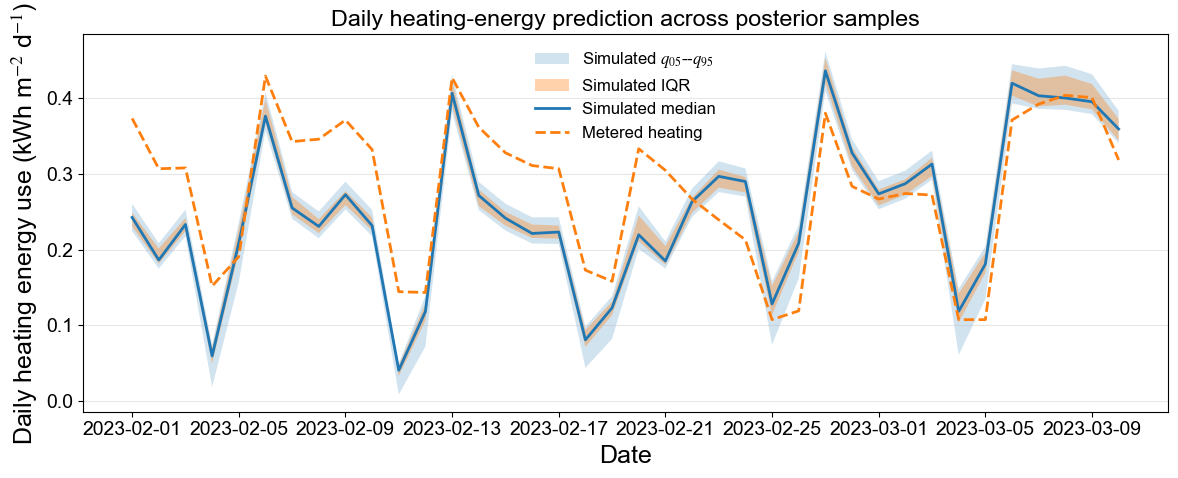

In [80]:
def make_sim_summary(Y):
    """
    Convert simulation ensemble Y into summary quantiles.

    Y:
        rows = timestamps
        columns = simulation samples
    """

    sim_summary = pd.DataFrame(index=Y.index)

    sim_summary["q05"] = Y.quantile(0.05, axis=1)
    sim_summary["q25"] = Y.quantile(0.25, axis=1)
    sim_summary["median"] = Y.median(axis=1)
    sim_summary["q75"] = Y.quantile(0.75, axis=1)
    sim_summary["q95"] = Y.quantile(0.95, axis=1)

    return sim_summary
sim_summary = make_sim_summary(posterior_Y)
coverage = plot_heating_coverage(
    sim_summary=sim_summary,
    meter_series=posterior_obs,
    start_date="2023-01-20",
    end_date="2023-03-10",
    y_label=r"Daily heating energy use (kWh m$^{-2}$ d$^{-1}$)",
    title="Daily heating-energy prediction across posterior samples"
)

In [ ]:
def calc_calibration_metrics(sim, obs, p=0):
    df = pd.concat(
        [sim.rename("sim"), obs.rename("obs")],
        axis=1
    ).dropna()

    if df.empty:
        raise ValueError("No overlapping timestamps between sim and obs.")

    n = len(df)

    if n <= p:
        raise ValueError("Number of matched timesteps must be larger than p.")

    error = df["sim"] - df["obs"]

    rmse = np.sqrt((error ** 2).sum() / (n - p))
    cvrmse = rmse / df["obs"].mean() * 100

    nmbe = error.sum() / ((n - p) * df["obs"].mean()) * 100

    return {
        "n": n,
        "p": p,
        "rmse": rmse,
        "cvrmse": cvrmse,
        "nmbe": nmbe,
        "sim_sum": df["sim"].sum(),
        "obs_sum": df["obs"].sum(),
        "bias_sum": df["sim"].sum() - df["obs"].sum(),
    }

posterior_median = posterior_Y.median(axis=1)

median_metrics = calc_calibration_metrics(
    sim=posterior_median,
    obs=posterior_obs.squeeze(),
    p=0
)

print(f"Posterior median CVRMSE = {median_metrics['cvrmse']:.2f}%")
print(f"Posterior median NMBE   = {median_metrics['nmbe']:.2f}%")

Posterior median CVRMSE = 26.05%
Posterior median NMBE   = -10.66%


# ECM evaluations

In [50]:
def get_ach_baseline_from_sample(sampled_params, default_params, geometry):
    """
    Calculate ach_vent_baseline and ach_infl_baseline for one sample.

    sampled_params only needs to contain varied/posterior parameters.
    Missing parameters are filled from default_params.
    """

    p = merge_params(sampled_params, default_params)

    ach_vent_baseline, ach_infl_baseline = make_ach(
        p=p,
        geometry=geometry,
        calc_ach=calc_ach,
    )

    return ach_vent_baseline, ach_infl_baseline, p

def make_ecm_occupancy_controller_params(
    sampled_params,
    default_params,
    geometry,
    ecm_type="default",
):
    """
    Create occupancy-controller parameters for ECM ventilation scenarios.

    ecm_type:
    - "default": occupied ACH = baseline, unoccupied ACH = 10% baseline
    - "strong":  occupied ACH = baseline, unoccupied ACH = 5% baseline
    """

    ach_vent_baseline, _, p = get_ach_baseline_from_sample(
        sampled_params=sampled_params,
        default_params=default_params,
        geometry=geometry,
    )

    if ecm_type == "default":
        return {
            "n_people": p["max_occupancy"],
            "ach_vent_baseline": ach_vent_baseline,
            "unoccupied_ach_fraction": 0.10,
            "occupancy_threshold_fraction": 0.10,
        }

    elif ecm_type == "strong":
        return {
            "n_people": p["max_occupancy"],
            "ach_vent_baseline": ach_vent_baseline,
            "unoccupied_ach_fraction": 0.05,
            "occupancy_threshold_fraction": 0.10,
        }

    else:
        raise ValueError(
            f"Unknown ecm_type: {ecm_type}. "
            "Use 'default' or 'strong'."
        )
    
def run_posterior_ecm_samples(
    posterior_TT,
    run_model_func,
    extra_params=None,
    controller_mode="original",
    controller_param_func=None,
):
    """
    Run ECM simulations using posterior-like parameter samples.

    controller_param_func:
        Optional function that receives sampled_params and returns
        occupancy_controller_params for that specific sample.
    """

    results = {}
    euis = {}

    if extra_params is None:
        extra_params = {}

    for sample_id, row in posterior_TT.iterrows():

        sampled_params = row.to_dict()
        sampled_params.update(extra_params)

        if controller_param_func is None:
            occupancy_controller_params = None
        else:
            occupancy_controller_params = controller_param_func(sampled_params)

        res, eui, _ = run_model_func(
            sampled_params=sampled_params,
            controller_mode=controller_mode,
            occupancy_controller_params=occupancy_controller_params,
        )

        results[sample_id] = res
        euis[sample_id] = eui

        print(f"Finished {sample_id}")

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

In [51]:
baseline_results, baseline_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params={
        "t_set_heating": 21.0,
    },
    controller_mode="original",
)

Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108


In [ ]:
ecm_setpoint_19_results, ecm_setpoint_19_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params={
        "t_set_heating": 19.0,
    },
    controller_mode="original",
)

ecm_setpoint_18_results, ecm_setpoint_18_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params={
        "t_set_heating": 18.0,
    },
    controller_mode="original",
)

ecm_3_occ_default_results, ecm_3_occ_default_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params={
        "t_set_heating": 21.0,
    },
    controller_mode="occupancy",
    controller_param_func=lambda sampled_params: make_ecm_occupancy_controller_params(
        sampled_params=sampled_params,
        default_params=DEFAULT_PARAMS,
        geometry=GEOMETRY,
        ecm_type="default",
    ),
)



Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108
Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108
Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108
Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108


In [68]:
ecm_4_occ_strong_results, ecm_4_occ_strong_eui = run_posterior_ecm_samples(
    posterior_TT=posterior_TT,
    run_model_func=run_model,
    extra_params={
        "t_set_heating": 20.0,
    },
    controller_mode="occupancy",
    controller_param_func=lambda sampled_params: make_ecm_occupancy_controller_params(
        sampled_params=sampled_params,
        default_params=DEFAULT_PARAMS,
        geometry=GEOMETRY,
        ecm_type="default",
    ),
)

Finished sample_054
Finished sample_055
Finished sample_111
Finished sample_141
Finished sample_082
Finished sample_104
Finished sample_002
Finished sample_068
Finished sample_036
Finished sample_108


In [69]:
import pandas as pd
import numpy as np


def calculate_ecm_savings(baseline_eui, ecm_eui, ecm_name):
    """
    Calculate absolute and relative ECM savings for each posterior sample.

    Positive values mean energy saving.
    Negative values mean energy increase.
    """

    df = pd.DataFrame(index=baseline_eui.index)

    df["ecm"] = ecm_name

    # Baseline energy use
    df["baseline_heating_eui"] = baseline_eui["HeatingEnergy"]
    df["baseline_cooling_eui"] = baseline_eui["CoolingEnergy"]
    df["baseline_total_hvac_eui"] = (
        df["baseline_heating_eui"] + df["baseline_cooling_eui"]
    )

    # ECM energy use
    df["ecm_heating_eui"] = ecm_eui["HeatingEnergy"]
    df["ecm_cooling_eui"] = ecm_eui["CoolingEnergy"]
    df["ecm_total_hvac_eui"] = (
        df["ecm_heating_eui"] + df["ecm_cooling_eui"]
    )

    # Absolute savings, kWh/m2
    df["heating_saving_abs"] = (
        df["baseline_heating_eui"] - df["ecm_heating_eui"]
    )

    df["cooling_saving_abs"] = (
        df["baseline_cooling_eui"] - df["ecm_cooling_eui"]
    )

    df["total_hvac_saving_abs"] = (
        df["baseline_total_hvac_eui"] - df["ecm_total_hvac_eui"]
    )

    # Relative savings, %
    df["heating_saving_pct"] = (
        df["heating_saving_abs"] / df["baseline_heating_eui"] * 100
    )

    df["cooling_saving_pct"] = (
        df["cooling_saving_abs"] / df["baseline_cooling_eui"].replace(0, np.nan) * 100
    )

    df["total_hvac_saving_pct"] = (
        df["total_hvac_saving_abs"] / df["baseline_total_hvac_eui"] * 100
    )

    return df

In [92]:
saving_setpoint_19 = calculate_ecm_savings(
    baseline_eui=baseline_eui,
    ecm_eui=ecm_setpoint_19_eui,
    ecm_name="ECM-1:\nHeating setpoint 21→19°C",
)

saving_setpoint_18 = calculate_ecm_savings(
    baseline_eui=baseline_eui,
    ecm_eui=ecm_setpoint_18_eui,
    ecm_name="ECM-2:\nHeating setpoint 21→18°C",
)

saving_occ_default = calculate_ecm_savings(
    baseline_eui=baseline_eui,
    ecm_eui=ecm_3_occ_default_eui,
    ecm_name="ECM-3:\nOccupancy ventilation,\nHeating setpoint 21°C",
)

saving_occ_strong = calculate_ecm_savings(
    baseline_eui=baseline_eui,
    ecm_eui=ecm_4_occ_strong_eui,
    ecm_name="ECM-4:\nOccupancy ventilation,\nHeating setpoint 21→19°C",
)

ecm_savings_all = pd.concat(
    [
        saving_setpoint_19,
        saving_setpoint_18,
        saving_occ_default,
        saving_occ_strong,
    ],
    axis=0,
)

In [96]:
import matplotlib.pyplot as plt


def plot_ecm_savings_boxplot(
    ecm_savings_all,
    value_col,
    y_label,
    title,
    figsize=(12, 8),
):
    """
    Boxplot of ECM savings across posterior samples.
    """

    plot_df = ecm_savings_all[["ecm", value_col]].copy()

    fig, ax = plt.subplots(figsize=figsize)

    plot_df.boxplot(
        column=value_col,
        by="ecm",
        ax=ax,
        rot=0,
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

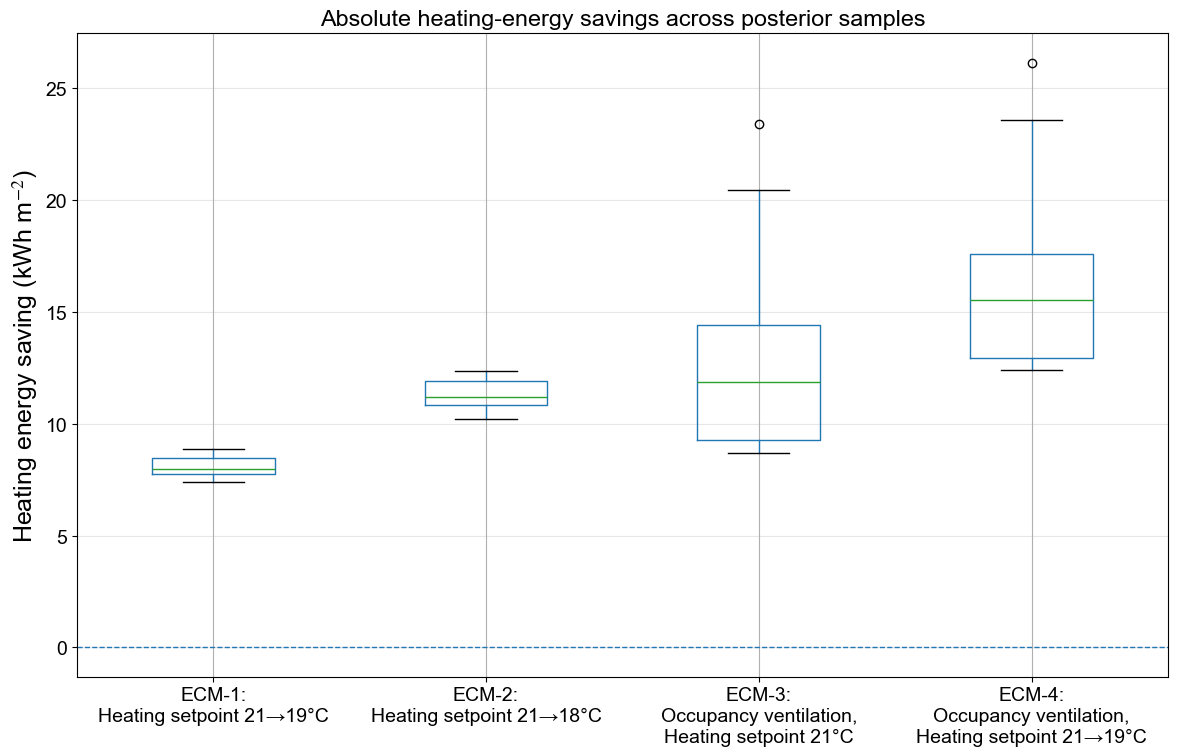

In [97]:
plot_ecm_savings_boxplot(
    ecm_savings_all=ecm_savings_all,
    value_col="heating_saving_abs",
    y_label=r"Heating energy saving (kWh m$^{-2}$)",
    title="Absolute heating-energy savings across posterior samples",
)

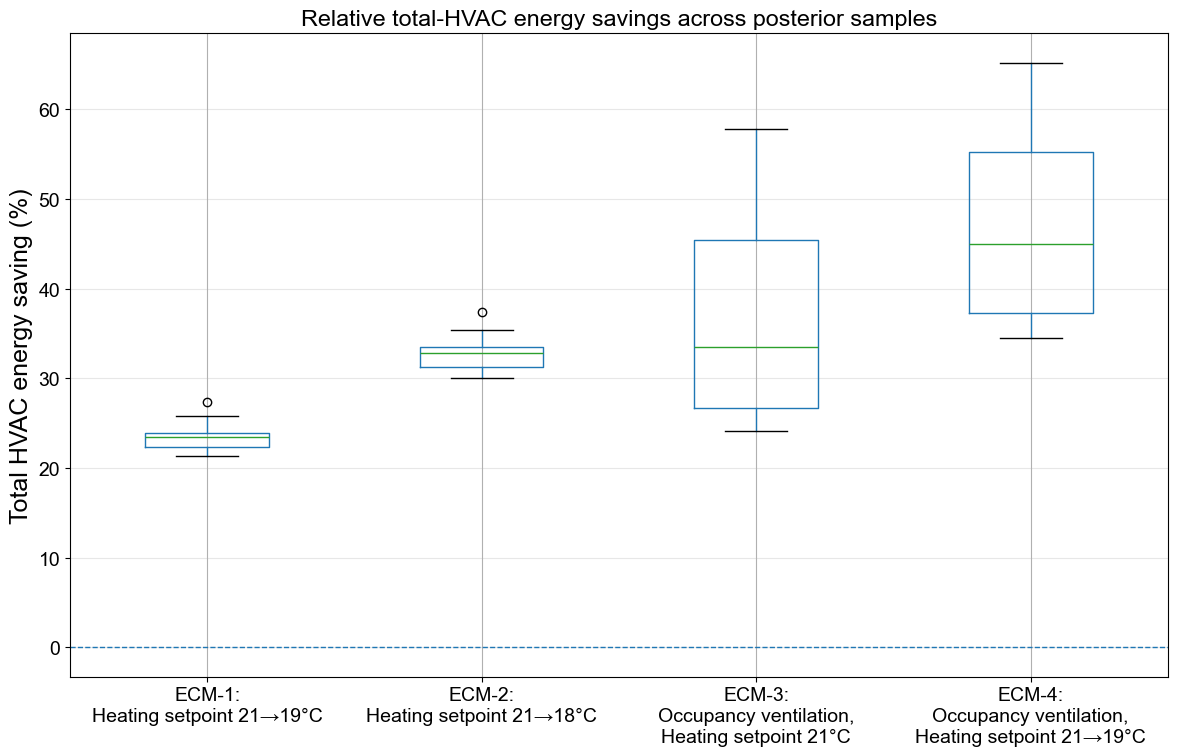

In [98]:
plot_ecm_savings_boxplot(
    ecm_savings_all=ecm_savings_all,
    value_col="total_hvac_saving_pct",
    y_label="Total HVAC energy saving (%)",
    title="Relative total-HVAC energy savings across posterior samples",
)